### 차트 작성 시 한글 깨짐 방지를 위한 koreanize-matplotlib 설치

In [33]:
!pip install koreanize-matplotlib

### 라이브러리 import

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet

### 1. 데이터 로드 및 분할

In [35]:
X, y = load_diabetes(return_X_y=True)

# 학습용/테스트용 데이터 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 2. 데이터 스케일링

In [36]:
scaler = StandardScaler()

# 학습 데이터 기준으로 스케일러 학습 및 변환
X_train_scaled = scaler.fit_transform(X_train)
# 테스트 데이터는 학습 데이터의 기준(mean, std)으로 변환만 수행
X_test_scaled = scaler.transform(X_test)

### 3. 모델 학습 및 평가: Ridge (L2 정규화)

In [37]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)

print(f"Ridge MSE: {ridge_mse:.2f}")
print(f"Ridge 회귀 계수:\n{np.round(ridge.coef_, 2)}")
print("-> 모든 변수의 계수가 0이 되지 않고 유지됨 (Shrinkage)")

Ridge MSE: 2892.01
Ridge 회귀 계수:
[  1.81 -11.45  25.73  16.73 -34.67  17.05   3.37  11.76  31.38   2.46]
-> 모든 변수의 계수가 0이 되지 않고 유지됨 (Shrinkage)


### 4. 모델 학습 및 평가: Lasso (L1 정규화)

In [38]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_selected_features = np.sum(lasso.coef_ != 0)

print(f"Lasso MSE: {lasso_mse:.2f}")
print(f"Lasso 회귀 계수:\n{np.round(lasso.coef_, 2)}")
print(f"Lasso가 선택한 변수 개수: {lasso_selected_features} / {X.shape[1]}")
print("-> 일부 변수의 계수가 정확히 0이 됨 (Feature Selection)")

Lasso MSE: 2824.57
Lasso 회귀 계수:
[ 0.69 -9.3  26.22 15.66 -8.23 -0.   -9.02  3.42 22.64  2.1 ]
Lasso가 선택한 변수 개수: 9 / 10
-> 일부 변수의 계수가 정확히 0이 됨 (Feature Selection)


### 5. 모델 학습 및 평가: Elastic-Net (L1 + L2)

In [39]:
# alpha: 규제 강도, l1_ratio: L1 규제의 비율 (0~1 사이)
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X_train_scaled, y_train)

el_pred = elastic_net.predict(X_test_scaled)
el_mse = mean_squared_error(y_test, el_pred)

print(f"ElasticNet(Basic) MSE: {el_mse:.2f}")
print(f"ElasticNet 회귀 계수:\n{np.round(elastic_net.coef_, 2)}")

ElasticNet(Basic) MSE: 2866.46
ElasticNet 회귀 계수:
[  1.9  -10.62  25.24  16.    -8.89  -2.08  -7.82   7.71  21.     3.15]


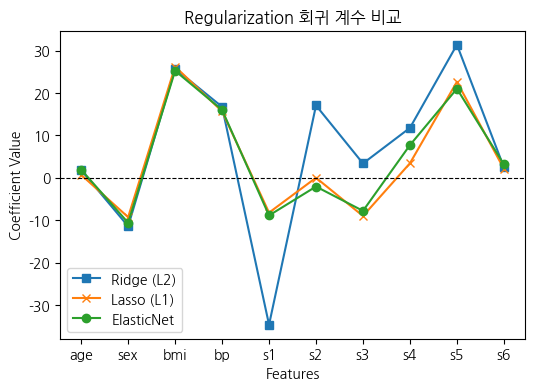


실습 완료!


In [40]:
feature_names = load_diabetes().feature_names

plt.figure(figsize=(6, 4))
plt.plot(feature_names, ridge.coef_, 's-', label='Ridge (L2)')
plt.plot(feature_names, lasso.coef_, 'x-', label='Lasso (L1)')
plt.plot(feature_names, elastic_net.coef_, 'o-', label='ElasticNet')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Regularization 회귀 계수 비교")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.legend()
plt.show()

print("\n실습 완료!")